## Partie 3 — Modélisation

In [31]:
# Imports
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix, precision_score, recall_score, f1_score, roc_curve, roc_auc_score
import statsmodels.api as sm
from statsmodels.stats.outliers_influence import variance_inflation_factor

# Rechargement du DataFrame depuis la Partie 2
team_matches_fin = pd.read_csv("fin_team_matches_bis.csv")
team_matches_fin["date"] = pd.to_datetime(team_matches_fin["date"])
print("✅ team_matches_fin chargé :", team_matches_fin.shape)

✅ team_matches_fin chargé : (8122, 62)


In [32]:
team_matches_fin

,match_id,mw_id,season_start,matchweek,date,team,opponent,goals_for,goals_against,attendance,...,opp_pressure_top4_4th,opp_pressure_title_1st,rivalry_intensity,rivalry_intensity_num,attendance_cat,attendance_cat_num,rest_days,result_num,win,is_home
0,2015_1_Arsenal_,J1_2015,2015,1,2015-08-09,Arsenal,West Ham United,0.0,2.0,59996.0,...,0.0,0.0,moyenne,1,grosse affluence,4.0,NaN,0.0,0,1
1,2015_2_Arsenal_,J2_2015,2015,2,2015-08-16,Arsenal,Crystal Palace,2.0,1.0,24732.0,...,1.0,1.0,neutre,0,faible affluence,1.0,7.0,2.0,1,0
2,2015_3_Arsenal_,J3_2015,2015,3,2015-08-24,Arsenal,Liverpool,0.0,0.0,60080.0,...,1.0,1.0,neutre,0,grosse affluence,4.0,8.0,1.0,0,1
3,2015_4_Arsenal_,J4_2015,2015,4,2015-08-29,Arsenal,Newcastle United,1.0,0.0,50388.0,...,1.0,1.0,neutre,0,grosse affluence,4.0,5.0,2.0,1,0
4,2015_5_Arsenal_,J5_2015,2015,5,2015-09-12,Arsenal,Stoke City,2.0,0.0,59963.0,...,1.0,1.0,neutre,0,grosse affluence,4.0,14.0,2.0,1,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
8117,2025_23_Wolves_,J23_2025,2025,23,2026-01-24,Wolves,Manchester City,0.0,2.0,52469.0,...,0.0,1.0,neutre,0,bonne affluence,3.0,6.0,0.0,0,0
8118,2025_24_Wolves_,J24_2025,2025,24,2026-01-31,Wolves,Bournemouth,0.0,2.0,30161.0,...,1.0,1.0,neutre,0,affluence moyenne,2.0,7.0,0.0,0,1
8119,2025_25_Wolves_,J25_2025,2025,25,2026-02-07,Wolves,Chelsea,1.0,3.0,29762.0,...,1.0,1.0,neutre,0,affluence moyenne,2.0,7.0,0.0,0,1
8120,2025_26_Wolves_,J26_2025,2025,26,2026-02-11,Wolves,Nottingham Forest,0.0,0.0,29921.0,...,1.0,1.0,neutre,0,affluence moyenne,2.0,4.0,1.0,0,0


In [33]:
team_matches_fin[["team",
    "opponent",
    "pressure_safety_18th",
    "pressure_top4_4th",
    "pressure_title_1st",
    "opp_pressure_safety_18th",
    "opp_pressure_top4_4th",
    "opp_pressure_title_1st"]].head(15)

,team,opponent,pressure_safety_18th,pressure_top4_4th,pressure_title_1st,opp_pressure_safety_18th,opp_pressure_top4_4th,opp_pressure_title_1st
0,Arsenal,West Ham United,0.000000,0.000000,0.0,0.000000,0.0,0.0
1,Arsenal,Crystal Palace,1.000000,1.000000,1.0,0.500000,1.0,1.0
2,Arsenal,Liverpool,0.666667,1.000000,1.0,0.166667,1.0,1.0
3,Arsenal,Newcastle United,0.666667,1.000000,1.0,1.000000,1.0,1.0
4,Arsenal,Stoke City,0.166667,1.000000,1.0,1.000000,1.0,1.0
5,Arsenal,Chelsea,0.000000,1.000000,1.0,0.666667,1.0,1.0
6,Arsenal,Leicester City,0.000000,1.000000,1.0,0.000000,1.0,1.0
7,Arsenal,Manchester Utd,0.000000,1.000000,1.0,0.000000,0.5,1.0
8,Arsenal,Watford,0.000000,0.833333,1.0,0.000000,1.0,1.0
9,Arsenal,Everton,0.000000,0.666667,1.0,0.000000,1.0,1.0


In [34]:
team_matches_fin["rest_days"] = (
    team_matches_fin["rest_days"]
    .round(0)
    .astype("Int64")
)

# Vérification
print(team_matches_fin["rest_days"].dtype)
print(team_matches_fin["rest_days"].isna().sum())


Int64
220


In [35]:
team_matches_fin["result_num"] = (
    team_matches_fin["result_num"]
    .round(0)
    .astype("Int64")  # supporte les NA
)

# Vérification
print(team_matches_fin["result_num"].dtype)
print(team_matches_fin["result_num"].isna().sum())


Int64
0


In [36]:
float_cols = team_matches_fin.select_dtypes(include=["float64"])
float_cols.dtypes


goals_for                   float64
goals_against               float64
attendance                  float64
cum_points_before           float64
cum_gf_after                float64
cum_ga_after                float64
cum_gd_after                float64
rank_before                 float64
opp_rank_before             float64
form5_points                float64
form5_gf                    float64
form5_ga                    float64
form5_gd                    float64
opp_form5_points            float64
opp_form5_gf                float64
opp_form5_ga                float64
opp_form5_gd                float64
form5_points_diff           float64
form5_gd_diff               float64
rank_diff                   float64
points_18                   float64
points_4                    float64
points_1                    float64
gap_to_18th                 float64
gap_to_4th                  float64
gap_to_1st                  float64
pressure_safety_18th        float64
pressure_top4_4th           

In [37]:
pressure_cols = [col for col in team_matches_fin.columns if "pressure" in col]
print(pressure_cols)


['pressure_safety_18th', 'pressure_top4_4th', 'pressure_title_1st', 'opp_pressure_safety_18th', 'opp_pressure_top4_4th', 'opp_pressure_title_1st']


In [38]:
cols_to_convert = [
    col for col in team_matches_fin.select_dtypes(include="number").columns
    if col not in pressure_cols
]

team_matches_fin[cols_to_convert] = (
    team_matches_fin[cols_to_convert]
    .round(0)
    .astype("Int64")
)

In [44]:
team_matches_fin.columns

Index(['match_id', 'mw_id', 'season_start', 'matchweek', 'date', 'team',
       'opponent', 'goals_for', 'goals_against', 'attendance', 'venue',
       'referee', 'points', 'cum_points_after', 'cum_points_before',
       'cum_gf_after', 'cum_ga_after', 'cum_gd_after', 'rank_after',
       'rank_before', 'opp_rank_before', 'opp_rank_after', 'form5_points',
       'form5_gf', 'form5_ga', 'form5_gd', 'opp_form5_points', 'opp_form5_gf',
       'opp_form5_ga', 'opp_form5_gd', 'form5_points_diff', 'form5_gd_diff',
       'rank_diff', 'points_18', 'points_4', 'points_1', 'gap_to_18th',
       'gap_to_4th', 'gap_to_1st', 'within6_of_safety_18th',
       'within6_of_top4_4th', 'within6_of_title_1st', 'pressure_safety_18th',
       'pressure_top4_4th', 'pressure_title_1st', 'opp_gap_to_18th',
       'opp_gap_to_4th', 'opp_gap_to_1st', 'opp_within6_of_safety_18th',
       'opp_within6_of_top4_4th', 'opp_within6_of_title_1st',
       'opp_pressure_safety_18th', 'opp_pressure_top4_4th',
       'opp

In [45]:
df = team_matches_fin.copy()

In [47]:
df.info()
df.describe()
df['result_num'].value_counts(normalize=True) #38% Victoire 

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8122 entries, 0 to 8121
Data columns (total 62 columns):
 #   Column                      Non-Null Count  Dtype         
---  ------                      --------------  -----         
 0   match_id                    8122 non-null   object        
 1   mw_id                       8122 non-null   object        
 2   season_start                8122 non-null   Int64         
 3   matchweek                   8122 non-null   Int64         
 4   date                        8122 non-null   datetime64[ns]
 5   team                        8122 non-null   object        
 6   opponent                    8122 non-null   object        
 7   goals_for                   8122 non-null   Int64         
 8   goals_against               8122 non-null   Int64         
 9   attendance                  7240 non-null   Int64         
 10  venue                       8122 non-null   object        
 11  referee                     8122 non-null   object      

result_num
0    0.382295
2    0.382295
1     0.23541
Name: proportion, dtype: Float64

In [48]:
import scipy.stats as stats

contingency = pd.crosstab(df['is_home'], df['result_num'])
chi2, p, dof, expected = stats.chi2_contingency(contingency)

print("p-value:", p)

p-value: 7.809822125478064e-36


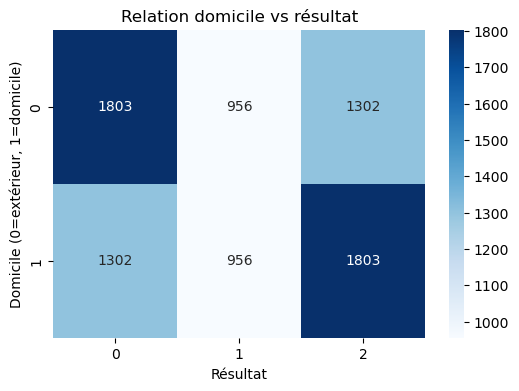

In [87]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(6,4))
sns.heatmap(contingency, annot=True, fmt='d', cmap='Blues')

plt.title("Relation domicile vs résultat")
plt.xlabel("Résultat")
plt.ylabel("Domicile (0=extérieur, 1=domicile)")

plt.show()

In [49]:
contingency

result_num,0,1,2
is_home,,,
0,1803,956,1302
1,1302,956,1803


In [51]:
dfb = df[['rank_diff', 'result_num']].dropna()

from scipy.stats import spearmanr
corr, p = spearmanr(dfb['rank_diff'], dfb['result_num'])
print(corr, p)

0.3379036857948384 2.7585135333747857e-210


In [54]:
dfc = df[['form5_points', 'result_num']].dropna()

import scipy.stats as stats

groups = [dfc[dfc['result_num']==i]['form5_points'] for i in dfc['result_num'].unique()]
f_stat, p = stats.f_oneway(*groups)

print("p-value:", p)

p-value: 1.3953466777315623e-55


<Axes: xlabel='result_num', ylabel='form5_points'>

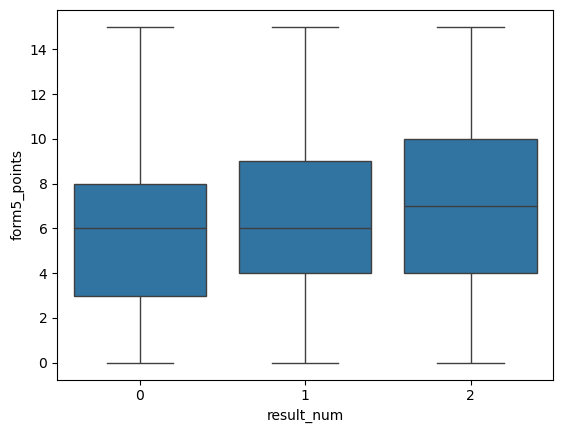

In [55]:
import seaborn as sns

sns.boxplot(x='result_num', y='form5_points', data=dfc)

In [61]:
within_col = [col for col in df.columns if 'within' in col]

df[within_col]

,within6_of_safety_18th,within6_of_top4_4th,within6_of_title_1st,opp_within6_of_safety_18th,opp_within6_of_top4_4th,opp_within6_of_title_1st
0,0,0,0,0,0,0
1,1,1,1,1,1,1
2,1,1,1,1,1,1
3,1,1,1,1,1,0
4,1,1,1,1,1,0
...,...,...,...,...,...,...
8117,0,0,0,0,0,0
8118,0,0,0,0,0,0
8119,0,0,0,0,1,0
8120,0,0,0,1,0,0


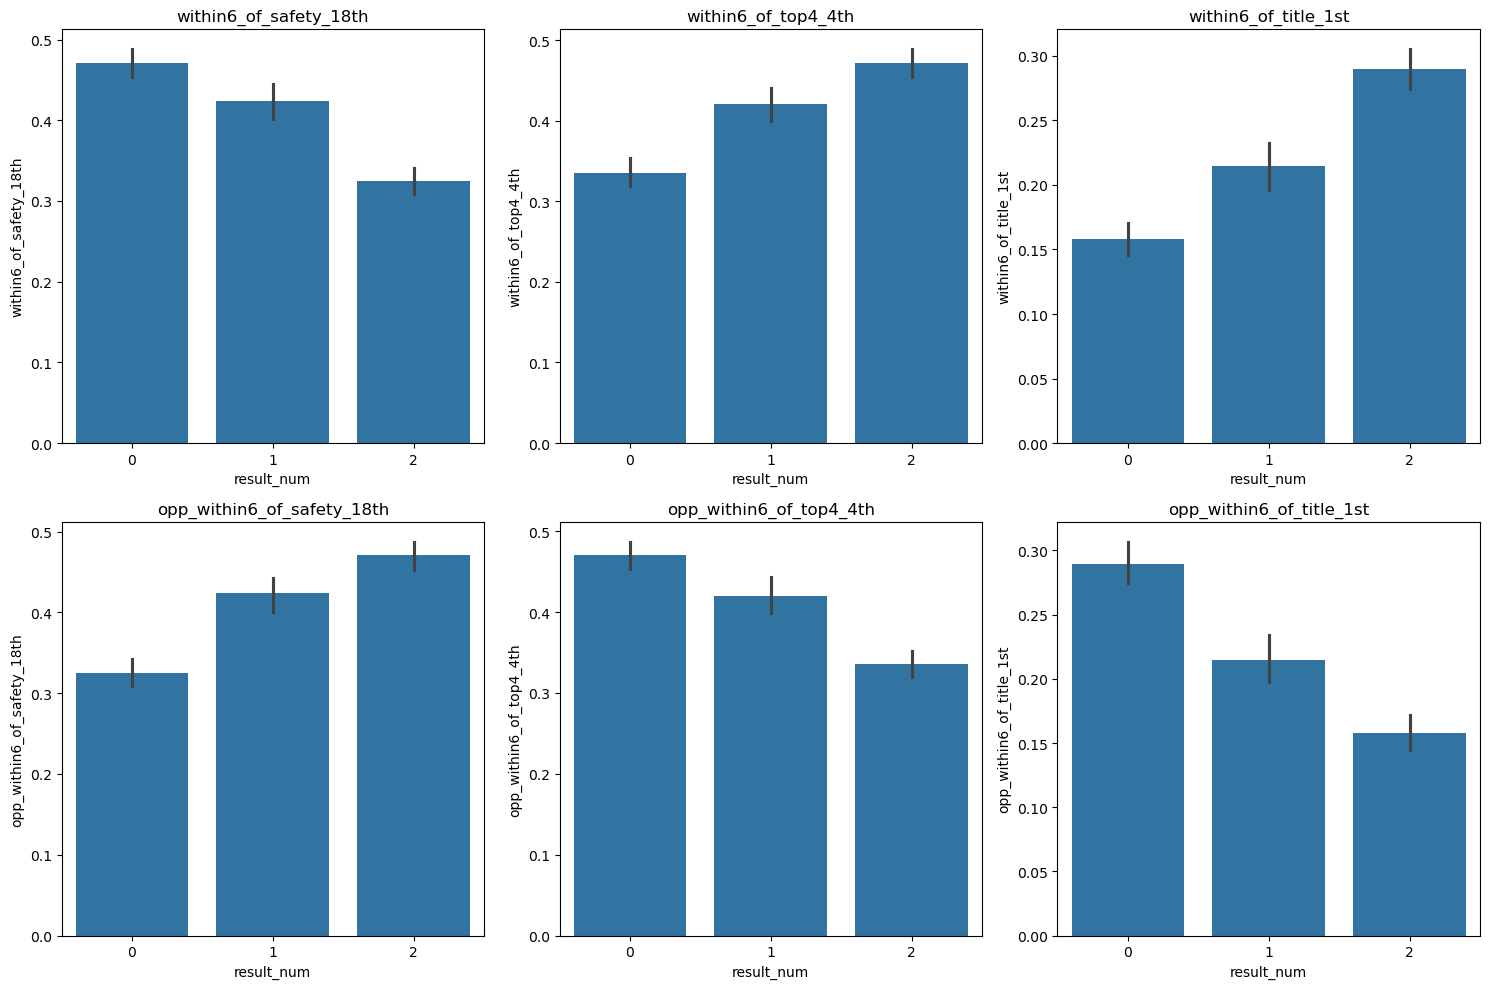

In [63]:
plt.figure(figsize=(15,10))

for i, col in enumerate(within_cols, 1):
    plt.subplot(2, 3, i)
    sns.barplot(x='result_num', y=col, data=df)
    plt.title(col)

plt.tight_layout()
plt.show()

In [65]:
features = [
    # contexte match
    'is_home', 'rest_days',

    # classement
    'rank_before', 'opp_rank_before', 'rank_diff',

    # forme récente
    'form5_points', 'form5_gf', 'form5_ga', 'form5_gd',
    'opp_form5_points', 'opp_form5_gf', 'opp_form5_ga', 'opp_form5_gd',
    'form5_points_diff', 'form5_gd_diff',

    # pression classement
    'pressure_safety_18th', 'pressure_top4_4th', 'pressure_title_1st',
    'opp_pressure_safety_18th', 'opp_pressure_top4_4th', 'opp_pressure_title_1st',

    # gaps classement
    'gap_to_18th', 'gap_to_4th', 'gap_to_1st',
    'opp_gap_to_18th', 'opp_gap_to_4th', 'opp_gap_to_1st',

    # contexte compétitif
    'within6_of_safety_18th', 'within6_of_top4_4th', 'within6_of_title_1st',
    'opp_within6_of_safety_18th', 'opp_within6_of_top4_4th', 'opp_within6_of_title_1st',

    # autres
    'rivalry_intensity_num', 'attendance_cat_num'
]

<Axes: >

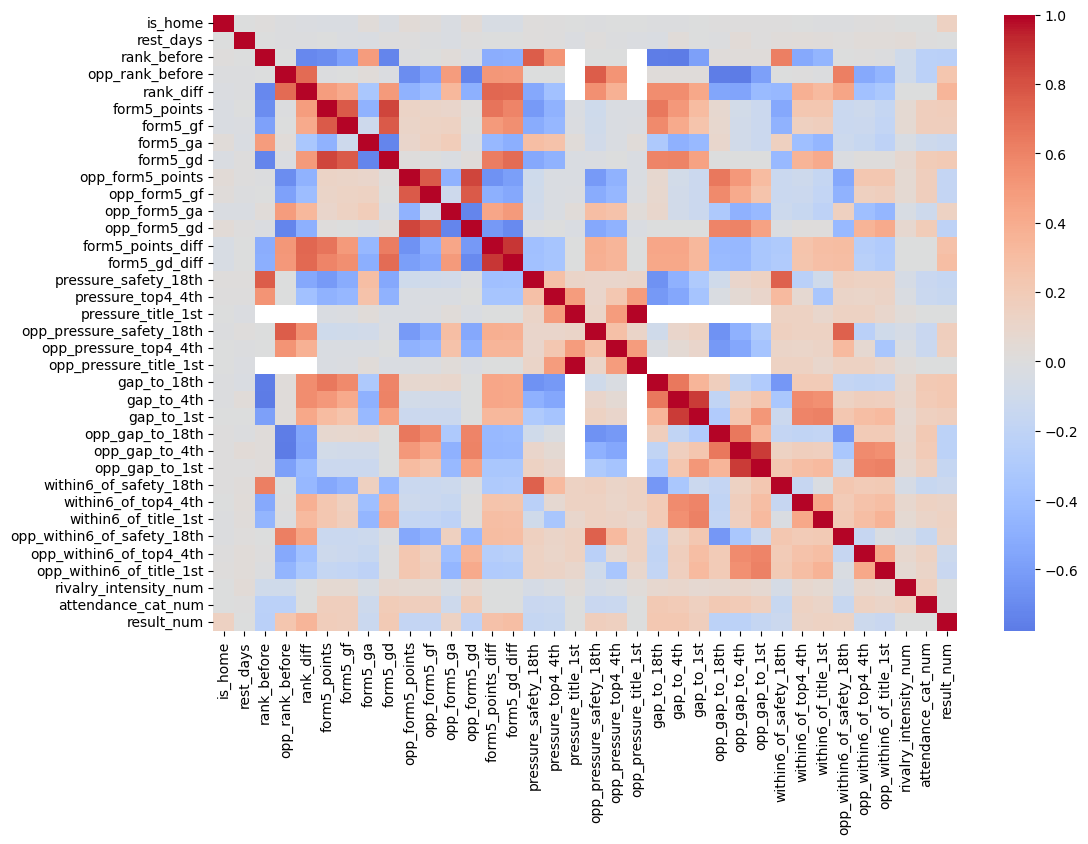

In [69]:
import seaborn as sns
import matplotlib.pyplot as plt

dfd = df[features + ['result_num']]

corr_matrix = dfd.corr(numeric_only=True)

plt.figure(figsize=(12,8))
sns.heatmap(corr_matrix, cmap="coolwarm", center=0)

In [71]:
X = df[features].copy()
y = df['result_num']

In [72]:
# enlever les NaN
X = X.fillna(0)

# vérifier
X.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8122 entries, 0 to 8121
Data columns (total 35 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   is_home                     8122 non-null   Int64  
 1   rest_days                   8122 non-null   Int64  
 2   rank_before                 8122 non-null   Int64  
 3   opp_rank_before             8122 non-null   Int64  
 4   rank_diff                   8122 non-null   Int64  
 5   form5_points                8122 non-null   Int64  
 6   form5_gf                    8122 non-null   Int64  
 7   form5_ga                    8122 non-null   Int64  
 8   form5_gd                    8122 non-null   Int64  
 9   opp_form5_points            8122 non-null   Int64  
 10  opp_form5_gf                8122 non-null   Int64  
 11  opp_form5_ga                8122 non-null   Int64  
 12  opp_form5_gd                8122 non-null   Int64  
 13  form5_points_diff           8122 

In [73]:
from sklearn.ensemble import RandomForestClassifier

model = RandomForestClassifier(random_state=42)
model.fit(X, y)

import pandas as pd

importances = pd.Series(model.feature_importances_, index=X.columns)
importances.sort_values(ascending=False).head(10)

rank_diff            0.057384
form5_gd_diff        0.051891
opp_gap_to_1st       0.048597
opp_gap_to_4th       0.048388
gap_to_1st           0.048377
gap_to_18th          0.047740
gap_to_4th           0.047522
opp_gap_to_18th      0.046625
rest_days            0.042467
form5_points_diff    0.042080
dtype: float64

In [74]:
train = df[df['season_start'] <= 2023]
test = df[df['season_start'] > 2023]

X_train = train[features].fillna(0)
y_train = train['result_num']

X_test = test[features].fillna(0)
y_test = test['result_num']

In [75]:
print("Train seasons:", sorted(train['season_start'].unique()))
print("Test seasons:", sorted(test['season_start'].unique()))

print("Train size:", len(train))
print("Test size:", len(test))

Train seasons: [np.int64(2015), np.int64(2016), np.int64(2017), np.int64(2018), np.int64(2019), np.int64(2020), np.int64(2021), np.int64(2022), np.int64(2023)]
Test seasons: [np.int64(2024), np.int64(2025)]
Train size: 6840
Test size: 1282


In [77]:
!pip install xgboost
from xgboost import XGBClassifier

model = XGBClassifier(
    n_estimators=200,
    max_depth=5,
    learning_rate=0.05,
    random_state=42
)

model.fit(X_train, y_train)

   ---------------------------------------- 0.0/101.7 MB ? eta -:--:--
   ----- ---------------------------------- 12.8/101.7 MB 65.1 MB/s eta 0:00:02
   ----------- ---------------------------- 28.3/101.7 MB 68.6 MB/s eta 0:00:02
   ----------------- ---------------------- 44.0/101.7 MB 70.3 MB/s eta 0:00:01
   ----------------------- ---------------- 58.7/101.7 MB 69.7 MB/s eta 0:00:01
   ----------------------------- ---------- 75.5/101.7 MB 71.6 MB/s eta 0:00:01
   ----------------------------------- ---- 91.0/101.7 MB 71.6 MB/s eta 0:00:01
   --------------------------------------  101.4/101.7 MB 71.9 MB/s eta 0:00:01
   --------------------------------------- 101.7/101.7 MB 66.5 MB/s eta 0:00:00


XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=None, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric=None, feature_types=None,
              feature_weights=None, gamma=None, grow_policy=None,
              importance_type=None, interaction_constraints=None,
              learning_rate=0.05, max_bin=None, max_cat_threshold=None,
              max_cat_to_onehot=None, max_delta_step=None, max_depth=5,
              max_leaves=None, min_child_weight=None, missing=nan,
              monotone_constraints=None, multi_strategy=None, n_estimators=200,
              n_jobs=None, num_parallel_tree=None, ...)

In [78]:
from sklearn.metrics import accuracy_score

y_pred = model.predict(X_test)

print("Accuracy:", accuracy_score(y_test, y_pred))

Accuracy: 0.48127925117004683


In [79]:
from sklearn.metrics import classification_report
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

         0.0       0.49      0.64      0.55       478
         1.0       0.18      0.01      0.01       326
         2.0       0.48      0.64      0.55       478

    accuracy                           0.48      1282
   macro avg       0.38      0.43      0.37      1282
weighted avg       0.41      0.48      0.41      1282



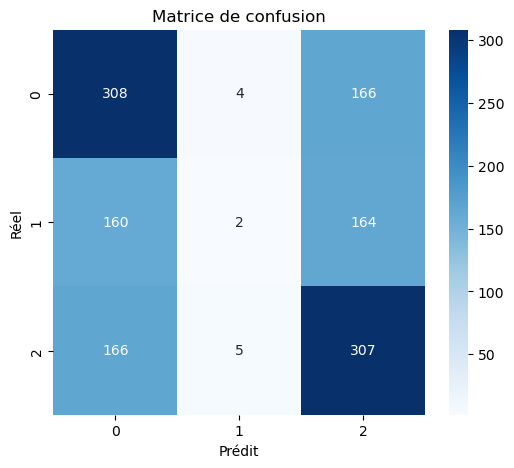

In [80]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.xlabel("Prédit")
plt.ylabel("Réel")
plt.title("Matrice de confusion")
plt.show()

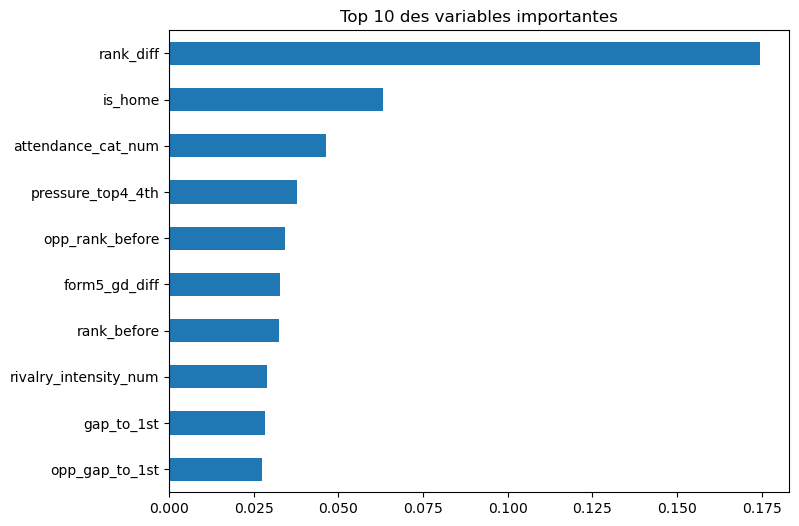

In [81]:
importances = pd.Series(model.feature_importances_, index=X.columns)
importances = importances.sort_values(ascending=True).tail(10)

plt.figure(figsize=(8,6))
importances.plot(kind='barh')
plt.title("Top 10 des variables importantes")
plt.show()

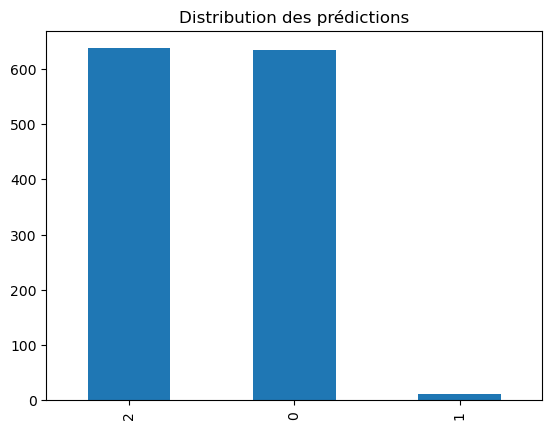

In [82]:
pd.Series(y_pred).value_counts().plot(kind='bar')
plt.title("Distribution des prédictions")
plt.show()

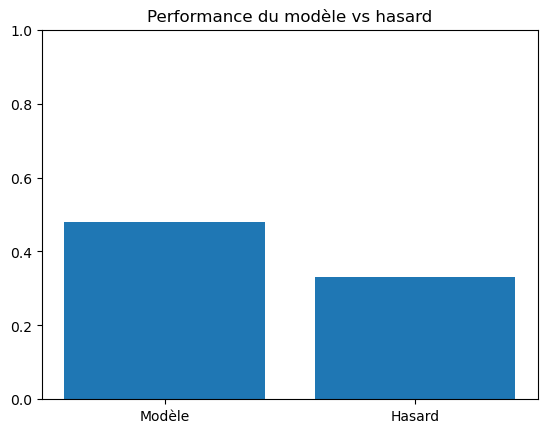

In [83]:
labels = ['Modèle', 'Hasard']
values = [0.48, 0.33]

plt.bar(labels, values)
plt.title("Performance du modèle vs hasard")
plt.ylim(0,1)
plt.show()

In [85]:
!pip install shap

   ---------------------------------------- 0.0/555.9 kB ? eta -:--:--
   --------------------------------------- 555.9/555.9 kB 20.0 MB/s eta 0:00:00

   -------------------- ------------------- 1/2 [shap]
   ---------------------------------------- 2/2 [shap]



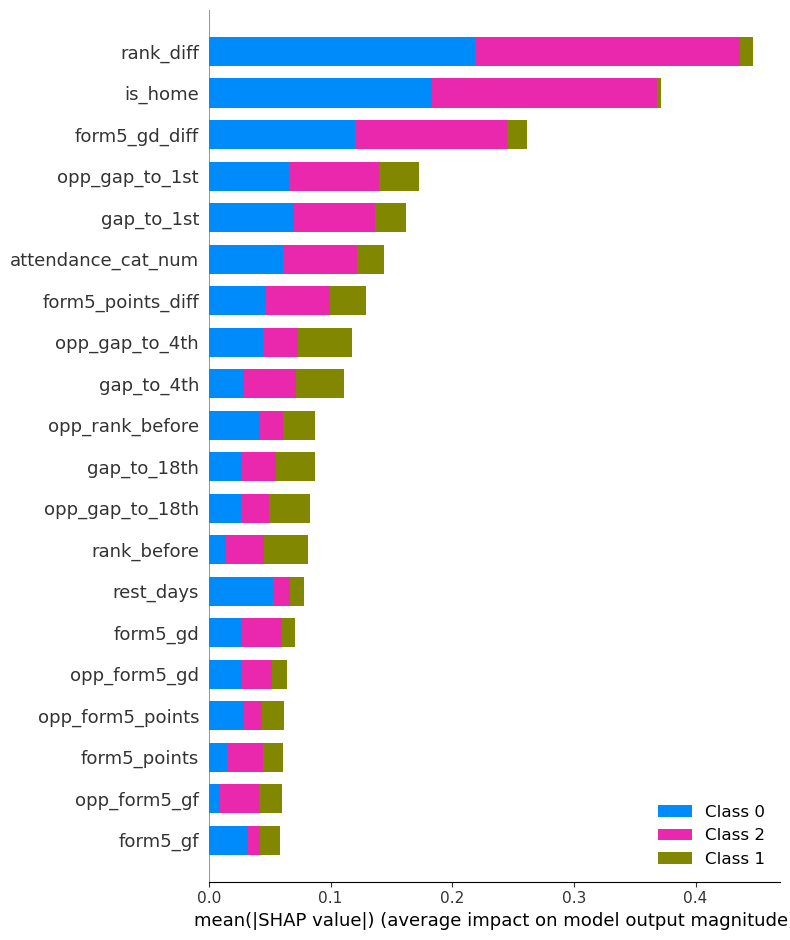

In [86]:
import shap

explainer = shap.Explainer(model)
shap_values = explainer(X_train)

shap.summary_plot(shap_values, X_train)